<div class="output_png output_subarea output_execute_result">
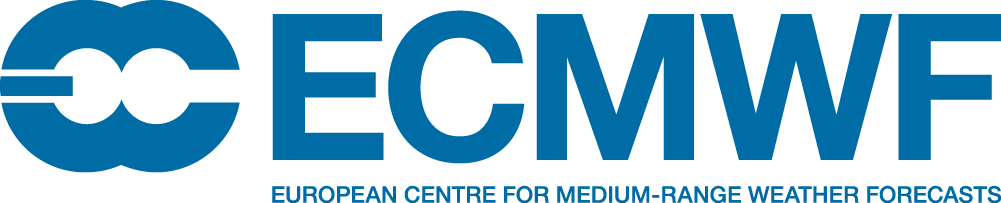
</div>

# 	Ensemble mean for 10 hPa temperature and geopotential

This notebook will provide you with guidance on how to explore and plot the ECMWF open dataset to produce the map from the ECMWF Open Charts web product.  
The original product can be found at this link: https://charts.ecmwf.int/products/medium-t10-mean-spread


<div class="output_png output_subarea output_execute_result">
<center>
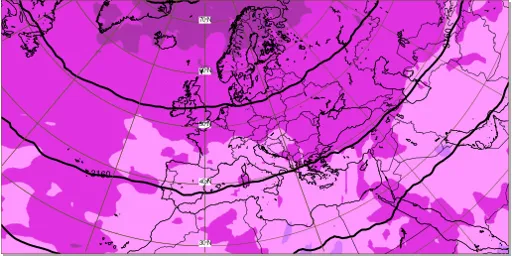</center>
</div>

The full list of available Open Data products can be found [here](https://www.ecmwf.int/en/forecasts/datasets/open-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF Open Data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain access to the full forecast dataset at higher resolution, please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes 2 parameters as input:

* [Temperature](https://codes.ecmwf.int/grib/param-db/130)
* [Geopotential height](https://codes.ecmwf.int/grib/param-db/156)


In this example, we will use: 
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data 

First, we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on the three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-opendata

In [1]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [ ]:
client = Client("ecmwf", beta=False)

In [3]:
parameters = ['t','gh']
filename1 = 'medium-t10-mean-pf.grib'
filename2 = 'medium-t10-mean-cf.grib'
filename1,filename2

('medium-t10-mean-pf.grib', 'medium-t10-mean-cf.grib')

To calculate the mean of temperature and geopotential height at 10 hPa, we need to retrieve all the ensemble members at the given time.  
We need to put **pf** as **type** and **enfo** as **stream** to download all 50 ensemble members. To download the control forecast, we put **fc** as **type** and **oper** as **stream**.

Setting "date" to 0 will download today's data. 
Removing "date" and "time" altogether from the request will download the latest data.  
Try commenting out the date and time to download the latest forecast!

In [4]:
client.retrieve(
    date=-1,
    time=0,
    step=[12],
    stream="enfo",
    type="pf",
    levtype="pl",
    levelist=[10],
    param=parameters,
    target=filename1
)
client.retrieve(
    date=-1,
    time=0,
    step=[12],
    stream="oper",
    type="fc",
    levtype="pl",
    levelist=[10],
    param=parameters,
    target=filename2
)

20260809000000-12h-enfo-ef.grib2:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


20260809000000-12h-oper-fc.grib2:   0%|          | 0.00/913k [00:00<?, ?B/s]

## Reading and processing the data
Now we can use **Metview's read() function** to read the files.

In [5]:
data1 = mv.read(filename1)
data2 = mv.read(filename2)
data = mv.merge(data1,data2)

The **describe()** function will give us the overview of the dataset.  

In [6]:
data.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
gh,isobaricInhPa,10,20260809,0,12,"1,10,...",156,od,"enfo,oper","fc,pf",0001
t,isobaricInhPa,10,20260809,0,12,"1,10,...",130,od,"enfo,oper","fc,pf",0001


And an overview of one parameter, where we can see more information, such as units or type of level.

In [7]:
data.describe('gh')

shortName,gh
name,Geopotential height
paramId,156
units,gpm
typeOfLevel,isobaricInhPa
level,10
date,20260809
time,0
step,12
number,"1,10,11,12,13,14,15,16,17,18,19,2,20,21,22,23,24,25,26,27,28,29,3,30,31,32,33,34,35,36,37,38,39,4,40,41,42,43,44,45,46,47,48,49,5,50,6,7,8,9,None"
class,od


We can use **ls()** function to list all the fields in the file we downloaded.

In [8]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
Message,,,,,,,,,,
0,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,12,regular_ll
1,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,5,regular_ll
2,ecmf,t,isobaricInhPa,10,20260809,0,12,pf,12,regular_ll
3,ecmf,t,isobaricInhPa,10,20260809,0,12,pf,5,regular_ll
4,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,4,regular_ll
5,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,3,regular_ll
6,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,2,regular_ll
7,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,1,regular_ll
8,ecmf,gh,isobaricInhPa,10,20260809,0,12,pf,38,regular_ll


### Calculating ensemble mean

The grib file contains both the parameters, and we will use the **select()** function to filter each one of them.

In [9]:
t = data.select(shortName="t")
gh = data.select(shortName="gh")
gh.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
gh,isobaricInhPa,10,20260809,0,12,"1,10,...",156,od,"enfo,oper","fc,pf",0001


Also, geopotential height has units gpm (geopotential meters), but on the ECMWF Open charts it is plotted in geopotential decameters. To reproduce the plot we need to divide by 10.

In [10]:
gh = gh / 10

In the end, we calculate the ensemble means of both parameters.

In [13]:
t_mean = mv.mean(t) - 273.15
gh_mean = mv.mean(gh)

## Plotting the data
And finally, we can plot the data on the map. 

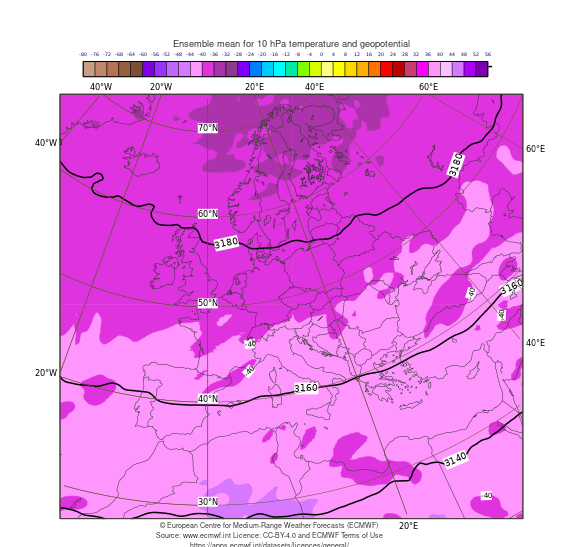

In [14]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
t_mean_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_all_fM80t56i4_v2")

gh_mean_contour = mv.mcont(legend= "on",
        contour_highlight = "off",
        contour_hilo = "off",
        contour_interval = 20,
        contour_label = "on",
        contour_label_frequency = 1,
        contour_label_height = 0.4,
        contour_level_selection_type = "interval",
        contour_line_colour = "black",
        contour_line_thickness=  3,
        contour_reference_level = 2000)

title = mv.mtext(
    text_lines=["Ensemble mean for 10 hPa temperature and geopotential", 
           "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H' where 'shortName=t'/> ",
           "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H' where 'shortName=t'/>, STEP: <grib_info key='step' where 'shortName=t'/>"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, t_mean, t_mean_shade, gh_mean, gh_mean_contour, title, ecmwf_text)

To generate the png file you can run the following cell.

In [12]:
png = mv.png_output(
      output_name = "medium-t10-mean-spread",   # specify relative or full path
      output_title = "medium-t10-mean-spread",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, tp_mean, tp_mean_shade, title, ecmwf_text)

Note that the plot produced using the open data dataset will slightly differ from the one in Open Charts. This is due to the different resolution of the data.  
Open Data has a 0.25x0.25 resolution, while the high-resolution data has a 0.1x0.1 grid.